# Results from EDA
* Load csv in this way to handle datetime type  
df = pd.read_csv("...", parse_dates=["signup_time", "purchase_time"])
* Need more derived cols but decide on what kind of model we use,  
 time series or tree based

### import deps

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### load data

In [3]:
df = pd.read_csv("../../data/raw/Fraud_Data.csv")

# Basic Analysis

In [4]:
df.head()

,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,7.327584e+08,0
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,3.503114e+08,0
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2.621474e+09,1
3,150084,2015-04-28 21:13:25,2015-05-04 13:54:50,44,ATGTXKYKUDUQN,SEO,Safari,M,41,3.840542e+09,0
4,221365,2015-07-21 07:09:52,2015-09-09 18:40:53,39,NAUITBZFJKHWW,Ads,Safari,M,45,4.155831e+08,0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 151112 entries, 0 to 151111
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   user_id         151112 non-null  int64  
 1   signup_time     151112 non-null  str    
 2   purchase_time   151112 non-null  str    
 3   purchase_value  151112 non-null  int64  
 4   device_id       151112 non-null  str    
 5   source          151112 non-null  str    
 6   browser         151112 non-null  str    
 7   sex             151112 non-null  str    
 8   age             151112 non-null  int64  
 9   ip_address      151112 non-null  float64
 10  class           151112 non-null  int64  
dtypes: float64(1), int64(4), str(6)
memory usage: 12.7 MB


In [6]:
df["signup_time"] = pd.to_datetime(
    df["signup_time"],
    format="%Y-%m-%d %H:%M:%S",
    errors="coerce"
)

df["purchase_time"] = pd.to_datetime(
    df["purchase_time"],
    format="%Y-%m-%d %H:%M:%S",
    errors="coerce"
)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 151112 entries, 0 to 151111
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   user_id         151112 non-null  int64         
 1   signup_time     151112 non-null  datetime64[us]
 2   purchase_time   151112 non-null  datetime64[us]
 3   purchase_value  151112 non-null  int64         
 4   device_id       151112 non-null  str           
 5   source          151112 non-null  str           
 6   browser         151112 non-null  str           
 7   sex             151112 non-null  str           
 8   age             151112 non-null  int64         
 9   ip_address      151112 non-null  float64       
 10  class           151112 non-null  int64         
dtypes: datetime64[us](2), float64(1), int64(4), str(4)
memory usage: 12.7 MB


# Columns

In [19]:
cols = ["user_id", "signup_time", "purchase_time",
 "device_id", "source",  "ip_address"]
categorical_cols = ["browser", "sex", "class"]
numerical_cols = ["purchase_value", "age"]

# UniVariate Analysis

## Categorical

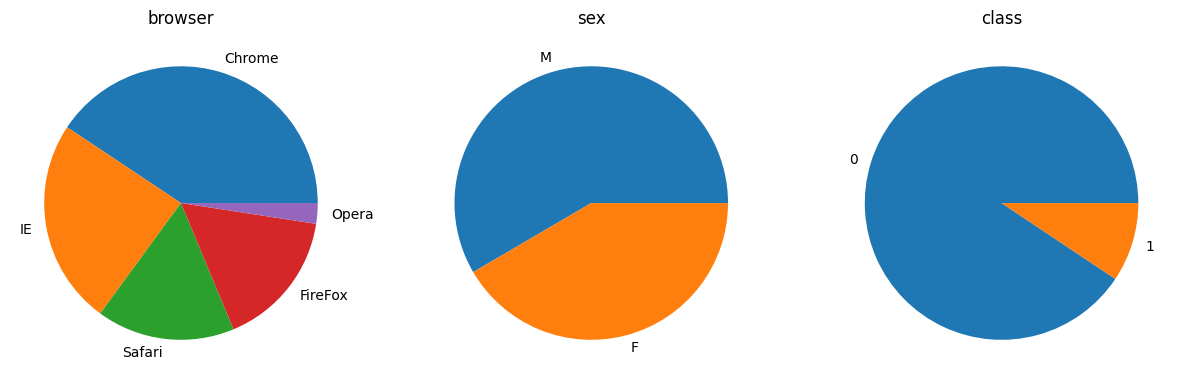

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    df[col].value_counts().plot(kind="pie", ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_ylabel("")
plt.show()

## Numerical

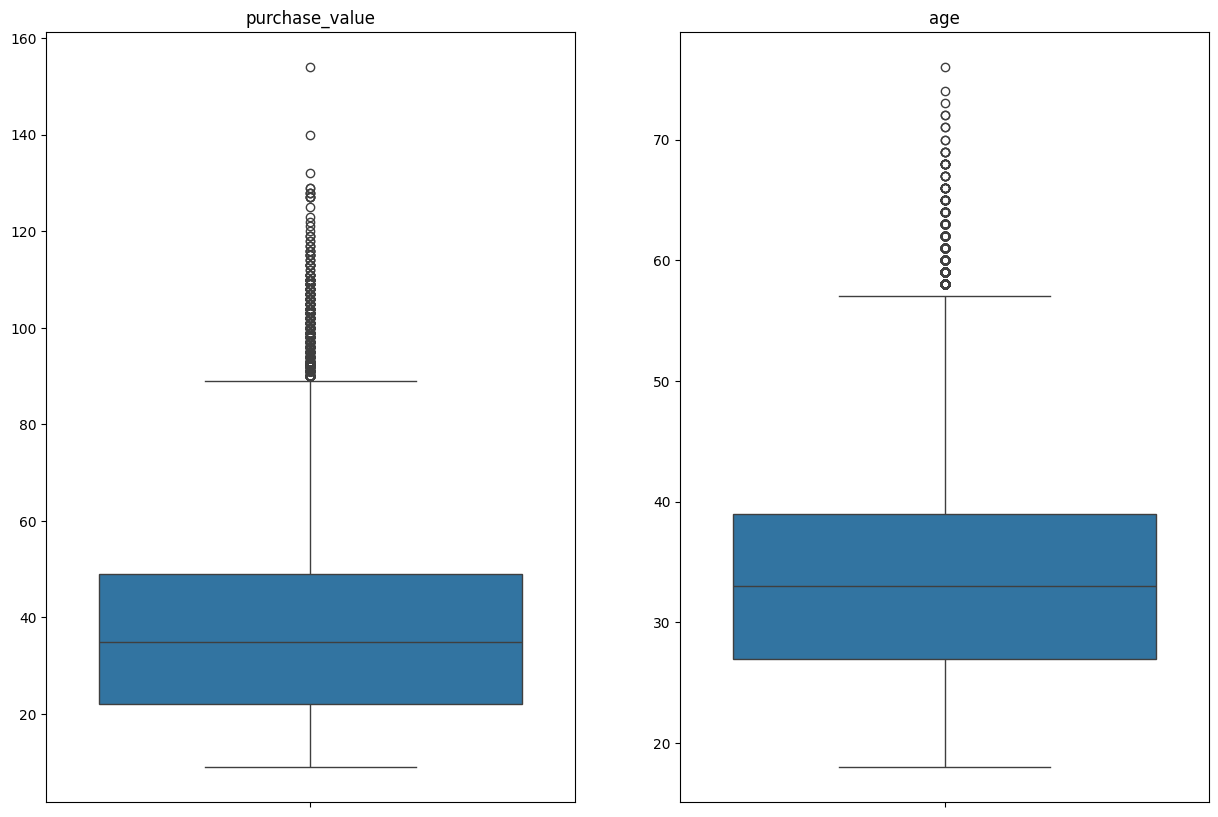

In [21]:
fig, axes = plt.subplots(1,2, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(df[col], ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_ylabel("")
plt.show()

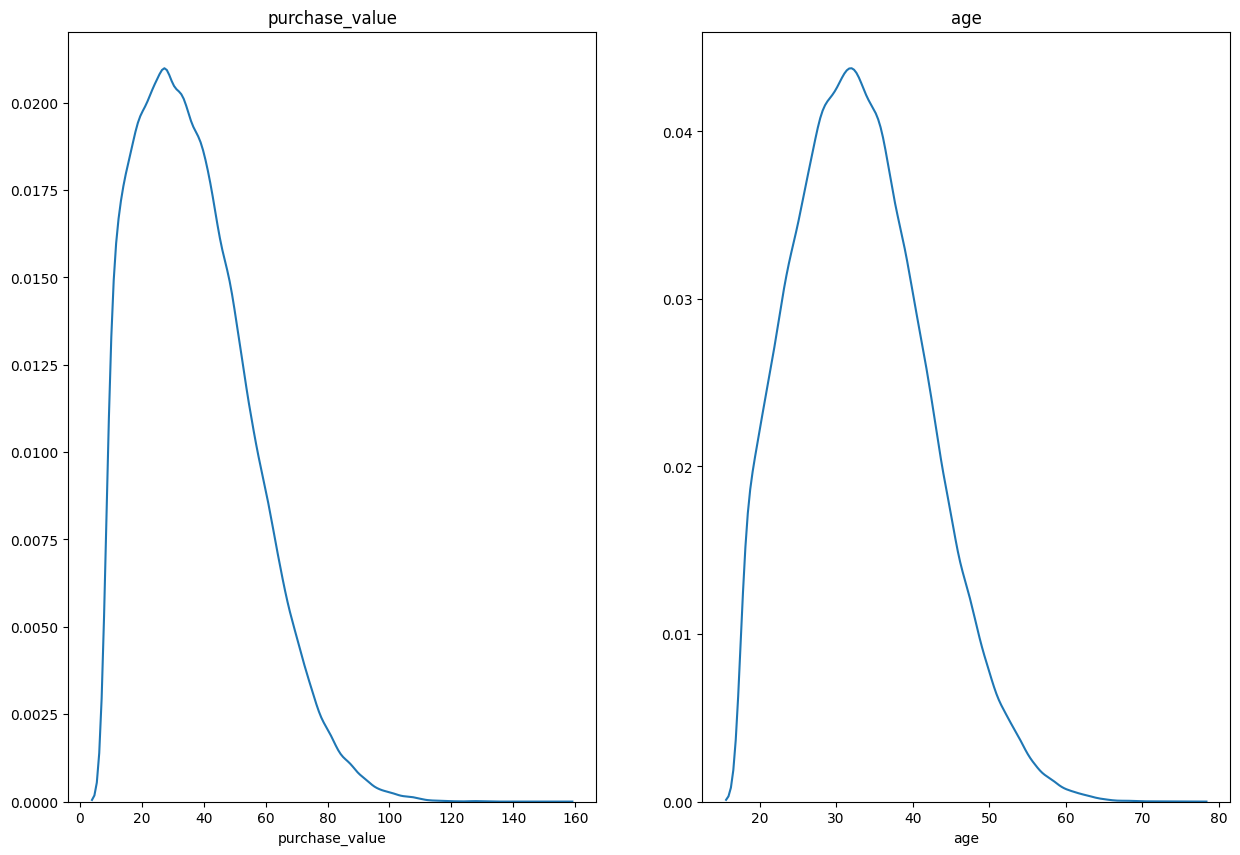

In [22]:
fig, axes = plt.subplots(1,2, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.kdeplot(df[col], ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_ylabel("")
plt.show()

# BiVariate Analysis

## Categorical

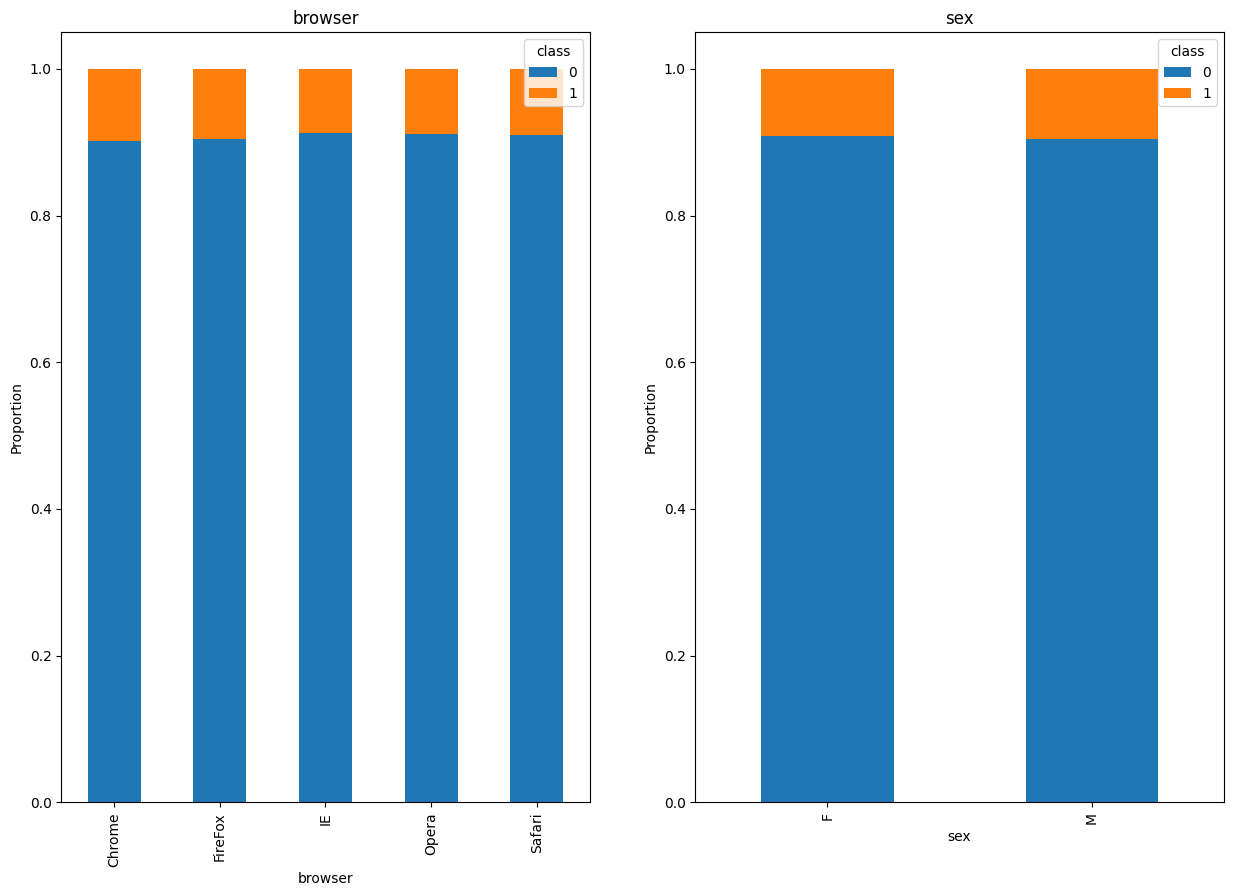

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(15, 10))
axes = axes.flatten()
for i, col in enumerate(categorical_cols[:-1]):
    crosstab = pd.crosstab(df[col], df["class"], normalize="index")
    crosstab.plot(kind="bar", stacked=True, ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_ylabel("Proportion")
plt.show()

## Numerical

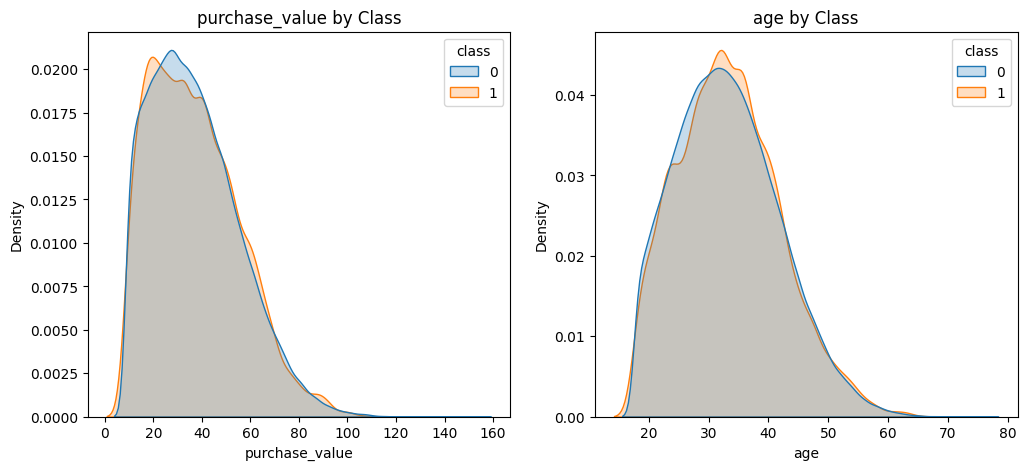

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.kdeplot(data=df, x=col, hue="class", fill=True, ax=axes[i], common_norm=False)
    axes[i].set_title(f"{col} by Class")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Density")
plt.show()

# MultiVariate Analysis

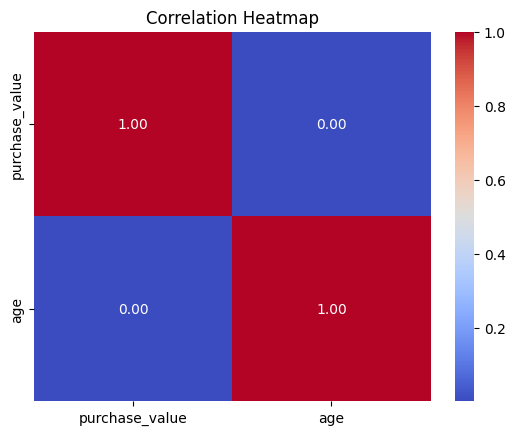

In [30]:

# Compute correlation matrix
corr_matrix = df[numerical_cols].corr(method="pearson")

# Plot heatmap
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()